In [2]:
from IPython.display import Markdown, display

text = """
# Лабораторна робота №1  

**Виконав:** студент групи ОІ-32 Прокопів Юрій  
**Прийняла:** асистентка Нарушинська О.О.  

### Тема:  
Постановка задачі та побудова аналітичної бази даних  

### Мета:  
Проаналізувати потреби клієнта, сформулювати бізнес- та аналітичні цілі, виконати первинне дослідження даних, створити реляційну базу даних та підключити її до інструменту візуалізації для пошуку інсайтів  

**Варіант – 7**  

---

### Опис Компанії-Замовника  
BreathWell Clinic — спеціалізований медичний заклад, що займається діагностикою, моніторингом та лікуванням захворювань дихальних шляхів, зокрема астми.  

### Запит  
Клініка прагне покращити діагностичну точність, щоб виявляти пацієнтів з астмою, навіть за мінімальними ознаками, та запобігти прогресуванню хвороби.  

### Пропозиція Реалізації  
Створити модель машинного навчання для класифікації ймовірності астми на основі анамнестичних, клініко-параклінічних даних і симптомів. Інструмент інтегрується в електронну медичну карту, допомагаючи лікарям виконати скринінг пацієнтів на ранніх етапах.  

---

## Завдання 1  
Відповідно до вашого варіанту (пункт «Ваш клієнт»), опишіть можливі три бізнес-цілі, а також сформулюйте до них цілі моделювання та критерії успіху.  

**Бізнес-ціль 1:** Покращення діагностичної точності астми  
- Ціль моделювання: Побудувати класифікаційну модель для прогнозування ймовірності наявності астми у пацієнта на основі симптомів та анамнестичних даних  
- Критерії успіху: Збільшити точність діагностики астми на 15% протягом 6 місяців. Модель має досягати точності не менше 85%  

**Бізнес-ціль 2:** Раннє виявлення пацієнтів з підвищеним ризиком астми  
- Ціль моделювання: Створити модель скринінгу для ідентифікації пацієнтів з високим ризиком розвитку астми серед загальної популяції відвідувачів  
- Критерії успіху: Збільшити кількість виявлених випадків астми на ранніх стадіях на 25% протягом року. Модель має досягати чутливості не менше 90%  

**Бізнес-ціль 3:** Оптимізація ресурсів клініки та зменшення часу обстеження  
- Ціль моделювання: Розробити модель для пріоритизації пацієнтів за рівнем негайності астматичних симптомів  
- Критерії успіху: Скоротити середній час очікування на обстеження на 30% та зменшити кількість повторних візитів на 20%. Модель має правильно класифікувати рівень негайності з точністю не менше 80%  

---

## Завдання 2  
Ознайомившись із пунктом «Запит клієнта», доповніть попередній список, додавши задану бізнес-мету, а також відповідні цілі моделювання і критерії успіху.  

**Бізнес-ціль 4:** Запобігання прогресуванню астми  
- Ціль моделювання: Створити прогностичну модель для визначення ймовірності прогресування астми від легкого до важкого ступеня на основі клінічних показників та поведінкових факторів  
- Критерії успіху бізнесу: Зменшити кількість госпіталізацій пацієнтів з астмою на 40% протягом року завдяки превентивним заходам  
- Критерії успіху моделювання: Модель має досягати AUC-ROC (бінарний класифікатор) не менше 0.85 для прогнозування прогресування астми  

---

## Завдання 3  
Проведіть аналіз даних підприємства (використовуючи наданий файл з Kaggle) та сформуйте:  
- звіт про дослідження даних (EDA)  
- звіт про якість даних (наявність пропусків, аномалій, розподіли тощо)  
"""
features_description = """
### Опис ознак датасету

| Назва ознаки              | Опис                                                                 | Пояснення |
|----------------------------|----------------------------------------------------------------------|-----------|
| **PatientID**              | Унікальний ідентифікатор пацієнта (5034–7425)                       | Використовується для відстеження кожного пацієнта |
| **Age**                    | Вік пацієнта (5–80 років)                                           | Скільки років пацієнту |
| **Gender**                 | Стать (0 = Чоловік, 1 = Жінка)                                      | Біологічна стать пацієнта |
| **Ethnicity**              | Етнічна належність (0 = Кавказька, 1 = Афроамериканець, 2 = Азіат, 3 = Інше) | Соціально-демографічна ознака |
| **EducationLevel**         | Рівень освіти (0 = Немає, 1 = Середня, 2 = Бакалавр, 3 = Вища)      | Найвищий рівень освіти |
| **BMI**                    | Індекс маси тіла (15–40)                                            | Вага пацієнта відносно зросту |
| **Smoking**                | Статус куріння (0 = Ні, 1 = Так)                                    | Чи палить пацієнт |
| **PhysicalActivity**       | Фізична активність на тиждень (0–10 год)                            | Скільки годин пацієнт займається спортом |
| **DietQuality**            | Оцінка якості харчування (0–10)                                     | Наскільки збалансоване харчування |
| **SleepQuality**           | Якість сну (4–10)                                                   | Суб’єктивна оцінка якості сну |
| **PollutionExposure**      | Рівень впливу забруднення (0–10)                                    | Оцінка впливу шкідливих факторів довкілля |
| **PollenExposure**         | Вплив пилку (0–10)                                                  | Ступінь впливу пилку на пацієнта |
| **DustExposure**           | Вплив пилу (0–10)                                                   | Ступінь впливу пилових частинок |
| **PetAllergy**             | Алергія на тварин (0 = Ні, 1 = Так)                                 | Чи є алергія на домашніх тварин |
| **FamilyHistoryAsthma**    | Сімейна історія астми (0 = Ні, 1 = Так)                             | Чи була астма у близьких родичів |
| **HistoryOfAllergies**     | Історія алергій (0 = Ні, 1 = Так)                                   | Чи мав пацієнт інші алергії |
| **Eczema**                 | Наявність екземи (0 = Ні, 1 = Так)                                  | Чи є у пацієнта екзема |
| **HayFever**               | Наявність сінної лихоманки (0 = Ні, 1 = Так)                        | Алергія на пилок |
| **GastroesophagealReflux** | Гастроезофагеальний рефлюкс (0 = Ні, 1 = Так)                       | Чи є у пацієнта ця хвороба |
| **LungFunctionFEV1**       | Форсований об’єм видиху за 1 секунду (1.0–4.0 л)                    | Ключовий показник функції легень |
| **LungFunctionFVC**        | Форсована життєва ємність легень (1.5–6.0 л)                        | Інший показник функції легень |
| **Wheezing**               | Свистяче дихання (0 = Ні, 1 = Так)                                  | Симптом астми |
| **ShortnessOfBreath**      | Задишка (0 = Ні, 1 = Так)                                           | Ускладнене дихання |
| **ChestTightness**         | Відчуття стискання у грудях (0 = Ні, 1 = Так)                       | Симптом астми |
| **Coughing**               | Кашель (0 = Ні, 1 = Так)                                            | Частий симптом |
| **NighttimeSymptoms**      | Нічні симптоми (0 = Ні, 1 = Так)                                    | Симптоми, що проявляються під час сну |
| **ExerciseInduced**        | Симптоми після фізичного навантаження (0 = Ні, 1 = Так)             | Чи провокує спорт прояви астми |
| **Diagnosis**              | Діагноз (0 = Ні, 1 = Так)                                           | Чи встановлено діагноз астми (цільова змінна) |
| **DoctorInCharge**         | Відповідальний лікар («Dr_Confid»)                                  | Конфіденційна інформація |
"""

display(Markdown(text))
display(Markdown(features_description))


# Лабораторна робота №1  

**Виконав:** студент групи ОІ-32 Прокопів Юрій  
**Прийняла:** асистентка Нарушинська О.О.  

### Тема:  
Постановка задачі та побудова аналітичної бази даних  

### Мета:  
Проаналізувати потреби клієнта, сформулювати бізнес- та аналітичні цілі, виконати первинне дослідження даних, створити реляційну базу даних та підключити її до інструменту візуалізації для пошуку інсайтів  

**Варіант – 7**  

---

### Опис Компанії-Замовника  
BreathWell Clinic — спеціалізований медичний заклад, що займається діагностикою, моніторингом та лікуванням захворювань дихальних шляхів, зокрема астми.  

### Запит  
Клініка прагне покращити діагностичну точність, щоб виявляти пацієнтів з астмою, навіть за мінімальними ознаками, та запобігти прогресуванню хвороби.  

### Пропозиція Реалізації  
Створити модель машинного навчання для класифікації ймовірності астми на основі анамнестичних, клініко-параклінічних даних і симптомів. Інструмент інтегрується в електронну медичну карту, допомагаючи лікарям виконати скринінг пацієнтів на ранніх етапах.  

---

## Завдання 1  
Відповідно до вашого варіанту (пункт «Ваш клієнт»), опишіть можливі три бізнес-цілі, а також сформулюйте до них цілі моделювання та критерії успіху.  

**Бізнес-ціль 1:** Покращення діагностичної точності астми  
- Ціль моделювання: Побудувати класифікаційну модель для прогнозування ймовірності наявності астми у пацієнта на основі симптомів та анамнестичних даних  
- Критерії успіху: Збільшити точність діагностики астми на 15% протягом 6 місяців. Модель має досягати точності не менше 85%  

**Бізнес-ціль 2:** Раннє виявлення пацієнтів з підвищеним ризиком астми  
- Ціль моделювання: Створити модель скринінгу для ідентифікації пацієнтів з високим ризиком розвитку астми серед загальної популяції відвідувачів  
- Критерії успіху: Збільшити кількість виявлених випадків астми на ранніх стадіях на 25% протягом року. Модель має досягати чутливості не менше 90%  

**Бізнес-ціль 3:** Оптимізація ресурсів клініки та зменшення часу обстеження  
- Ціль моделювання: Розробити модель для пріоритизації пацієнтів за рівнем негайності астматичних симптомів  
- Критерії успіху: Скоротити середній час очікування на обстеження на 30% та зменшити кількість повторних візитів на 20%. Модель має правильно класифікувати рівень негайності з точністю не менше 80%  

---

## Завдання 2  
Ознайомившись із пунктом «Запит клієнта», доповніть попередній список, додавши задану бізнес-мету, а також відповідні цілі моделювання і критерії успіху.  

**Бізнес-ціль 4:** Запобігання прогресуванню астми  
- Ціль моделювання: Створити прогностичну модель для визначення ймовірності прогресування астми від легкого до важкого ступеня на основі клінічних показників та поведінкових факторів  
- Критерії успіху бізнесу: Зменшити кількість госпіталізацій пацієнтів з астмою на 40% протягом року завдяки превентивним заходам  
- Критерії успіху моделювання: Модель має досягати AUC-ROC (бінарний класифікатор) не менше 0.85 для прогнозування прогресування астми  

---

## Завдання 3  
Проведіть аналіз даних підприємства (використовуючи наданий файл з Kaggle) та сформуйте:  
- звіт про дослідження даних (EDA)  
- звіт про якість даних (наявність пропусків, аномалій, розподіли тощо)  



### Опис ознак датасету

| Назва ознаки              | Опис                                                                 | Пояснення |
|----------------------------|----------------------------------------------------------------------|-----------|
| **PatientID**              | Унікальний ідентифікатор пацієнта (5034–7425)                       | Використовується для відстеження кожного пацієнта |
| **Age**                    | Вік пацієнта (5–80 років)                                           | Скільки років пацієнту |
| **Gender**                 | Стать (0 = Чоловік, 1 = Жінка)                                      | Біологічна стать пацієнта |
| **Ethnicity**              | Етнічна належність (0 = Кавказька, 1 = Афроамериканець, 2 = Азіат, 3 = Інше) | Соціально-демографічна ознака |
| **EducationLevel**         | Рівень освіти (0 = Немає, 1 = Середня, 2 = Бакалавр, 3 = Вища)      | Найвищий рівень освіти |
| **BMI**                    | Індекс маси тіла (15–40)                                            | Вага пацієнта відносно зросту |
| **Smoking**                | Статус куріння (0 = Ні, 1 = Так)                                    | Чи палить пацієнт |
| **PhysicalActivity**       | Фізична активність на тиждень (0–10 год)                            | Скільки годин пацієнт займається спортом |
| **DietQuality**            | Оцінка якості харчування (0–10)                                     | Наскільки збалансоване харчування |
| **SleepQuality**           | Якість сну (4–10)                                                   | Суб’єктивна оцінка якості сну |
| **PollutionExposure**      | Рівень впливу забруднення (0–10)                                    | Оцінка впливу шкідливих факторів довкілля |
| **PollenExposure**         | Вплив пилку (0–10)                                                  | Ступінь впливу пилку на пацієнта |
| **DustExposure**           | Вплив пилу (0–10)                                                   | Ступінь впливу пилових частинок |
| **PetAllergy**             | Алергія на тварин (0 = Ні, 1 = Так)                                 | Чи є алергія на домашніх тварин |
| **FamilyHistoryAsthma**    | Сімейна історія астми (0 = Ні, 1 = Так)                             | Чи була астма у близьких родичів |
| **HistoryOfAllergies**     | Історія алергій (0 = Ні, 1 = Так)                                   | Чи мав пацієнт інші алергії |
| **Eczema**                 | Наявність екземи (0 = Ні, 1 = Так)                                  | Чи є у пацієнта екзема |
| **HayFever**               | Наявність сінної лихоманки (0 = Ні, 1 = Так)                        | Алергія на пилок |
| **GastroesophagealReflux** | Гастроезофагеальний рефлюкс (0 = Ні, 1 = Так)                       | Чи є у пацієнта ця хвороба |
| **LungFunctionFEV1**       | Форсований об’єм видиху за 1 секунду (1.0–4.0 л)                    | Ключовий показник функції легень |
| **LungFunctionFVC**        | Форсована життєва ємність легень (1.5–6.0 л)                        | Інший показник функції легень |
| **Wheezing**               | Свистяче дихання (0 = Ні, 1 = Так)                                  | Симптом астми |
| **ShortnessOfBreath**      | Задишка (0 = Ні, 1 = Так)                                           | Ускладнене дихання |
| **ChestTightness**         | Відчуття стискання у грудях (0 = Ні, 1 = Так)                       | Симптом астми |
| **Coughing**               | Кашель (0 = Ні, 1 = Так)                                            | Частий симптом |
| **NighttimeSymptoms**      | Нічні симптоми (0 = Ні, 1 = Так)                                    | Симптоми, що проявляються під час сну |
| **ExerciseInduced**        | Симптоми після фізичного навантаження (0 = Ні, 1 = Так)             | Чи провокує спорт прояви астми |
| **Diagnosis**              | Діагноз (0 = Ні, 1 = Так)                                           | Чи встановлено діагноз астми (цільова змінна) |
| **DoctorInCharge**         | Відповідальний лікар («Dr_Confid»)                                  | Конфіденційна інформація |


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

df = pd.read_csv('asthma_disease_data.csv')

print("Базова інформація про датасет:")
print(f"Розмір датасету: {df.shape}")
print(f"Кількість записів: {df.shape[0]}")
print(f"Кількість ознак: {df.shape[1]}")

df

Базова інформація про датасет:
Розмір датасету: (2392, 29)
Кількість записів: 2392
Кількість ознак: 29


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,PhysicalActivity,DietQuality,SleepQuality,...,LungFunctionFEV1,LungFunctionFVC,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis,DoctorInCharge
0,5034,63,0,1,0,15.848744,0,0.894448,5.488696,8.701003,...,1.369051,4.941206,0,0,1,0,0,1,0,Dr_Confid
1,5035,26,1,2,2,22.757042,0,5.897329,6.341014,5.153966,...,2.197767,1.702393,1,0,0,1,1,1,0,Dr_Confid
2,5036,57,0,2,1,18.395396,0,6.739367,9.196237,6.840647,...,1.698011,5.022553,1,1,1,0,1,1,0,Dr_Confid
3,5037,40,1,2,1,38.515278,0,1.404503,5.826532,4.253036,...,3.032037,2.300159,1,0,1,1,1,0,0,Dr_Confid
4,5038,61,0,0,3,19.283802,0,4.604493,3.127048,9.625799,...,3.470589,3.067944,1,1,1,0,0,1,0,Dr_Confid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,7421,43,1,0,2,29.059613,0,3.019854,6.119637,8.300960,...,3.125249,5.166032,0,1,0,0,0,1,1,Dr_Confid
2388,7422,18,1,0,1,20.740850,0,5.805180,4.386992,7.731192,...,1.132977,5.509502,0,0,0,1,1,0,1,Dr_Confid
2389,7423,54,0,3,2,37.079560,0,4.735169,8.214064,7.483521,...,1.685962,3.346877,1,0,1,1,0,1,1,Dr_Confid
2390,7424,46,1,0,2,23.444712,0,9.672637,7.362861,6.717272,...,3.481549,1.713274,0,1,1,0,1,1,0,Dr_Confid


In [69]:
print("Перші 5 записів датасету:")
display(df.head())

print("\nІнформація про типи даних:")
print(df.info())

print("\nСтатистичний опис числових змінних:")
display(df.describe())

target_columns = [col for col in df.columns if any(word in col.lower() 
                  for word in ['asthma', 'diagnosis', 'target', 'disease', 'condition'])]
if target_columns:
    print(f"\nЗнайдені потенційні цільові змінні: {target_columns}")
    for col in target_columns:
        print(f"\nРозподіл значень у колонці '{col}':")
        print(df[col].value_counts())

Перші 5 записів датасету:


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,PhysicalActivity,DietQuality,SleepQuality,...,LungFunctionFEV1,LungFunctionFVC,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis,DoctorInCharge
0,5034,63,0,1,0,15.848744,0,0.894448,5.488696,8.701003,...,1.369051,4.941206,0,0,1,0,0,1,0,Dr_Confid
1,5035,26,1,2,2,22.757042,0,5.897329,6.341014,5.153966,...,2.197767,1.702393,1,0,0,1,1,1,0,Dr_Confid
2,5036,57,0,2,1,18.395396,0,6.739367,9.196237,6.840647,...,1.698011,5.022553,1,1,1,0,1,1,0,Dr_Confid
3,5037,40,1,2,1,38.515278,0,1.404503,5.826532,4.253036,...,3.032037,2.300159,1,0,1,1,1,0,0,Dr_Confid
4,5038,61,0,0,3,19.283802,0,4.604493,3.127048,9.625799,...,3.470589,3.067944,1,1,1,0,0,1,0,Dr_Confid



Інформація про типи даних:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PatientID               2392 non-null   int64  
 1   Age                     2392 non-null   int64  
 2   Gender                  2392 non-null   int64  
 3   Ethnicity               2392 non-null   int64  
 4   EducationLevel          2392 non-null   int64  
 5   BMI                     2392 non-null   float64
 6   Smoking                 2392 non-null   int64  
 7   PhysicalActivity        2392 non-null   float64
 8   DietQuality             2392 non-null   float64
 9   SleepQuality            2392 non-null   float64
 10  PollutionExposure       2392 non-null   float64
 11  PollenExposure          2392 non-null   float64
 12  DustExposure            2392 non-null   float64
 13  PetAllergy              2392 non-null   int64  
 14  FamilyHistor

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,PhysicalActivity,DietQuality,SleepQuality,...,GastroesophagealReflux,LungFunctionFEV1,LungFunctionFVC,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,...,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,6229.500000,42.137960,0.493311,0.669732,1.307274,27.244877,0.141722,5.051786,5.022867,7.019012,...,0.158027,2.548564,3.741270,0.596154,0.500418,0.503344,0.503344,0.602425,0.604933,0.051839
std,690.655244,21.606655,0.500060,0.986120,0.898242,7.201628,0.348838,2.903574,2.909980,1.732475,...,0.364842,0.861809,1.303689,0.490770,0.500104,0.500093,0.500093,0.489499,0.488967,0.221749
min,5034.000000,5.000000,0.000000,0.000000,0.000000,15.031803,0.000000,0.001740,0.003031,4.001437,...,0.000000,1.000459,1.500045,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5631.750000,23.000000,0.000000,0.000000,1.000000,20.968313,0.000000,2.578333,2.432043,5.498500,...,0.000000,1.824113,2.607489,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6229.500000,42.000000,0.000000,0.000000,1.000000,27.052202,0.000000,5.016881,5.115383,6.975839,...,0.000000,2.553244,3.734982,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
75%,6827.250000,61.000000,1.000000,1.000000,2.000000,33.555903,0.000000,7.540234,7.544216,8.526950,...,0.000000,3.292897,4.864121,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,7425.000000,79.000000,1.000000,3.000000,3.000000,39.985611,1.000000,9.995809,9.999904,9.996235,...,1.000000,3.999719,5.999421,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Знайдені потенційні цільові змінні: ['FamilyHistoryAsthma', 'Diagnosis']

Розподіл значень у колонці 'FamilyHistoryAsthma':
FamilyHistoryAsthma
0    1672
1     720
Name: count, dtype: int64

Розподіл значень у колонці 'Diagnosis':
Diagnosis
0    2268
1     124
Name: count, dtype: int64


In [70]:
import pandas as pd
df = pd.read_csv('asthma_disease_data.csv')
def analyze_missing_values(df):
    
    print("Детальний аналіз пропущених значень:")
    print("="*50)
    
    standard_missing = df.isnull().sum()
    
    possible_missing_values = ['', ' ', 'N/A', 'n/a', 'NA', 'na', 'NULL', 'null', 
                              'NaN', 'nan', '?', '-', '--', 'unknown', 'Unknown', 
                              'UNKNOWN', 'missing', 'Missing', 'MISSING']
    
    missing_analysis = []
    
    for column in df.columns:
        null_count = df[column].isnull().sum()
        
        additional_missing = 0
        if df[column].dtype == 'object':
            for missing_val in possible_missing_values:
                additional_missing += (df[column] == missing_val).sum()
        
        total_missing = null_count + additional_missing
        percent_missing = (total_missing / len(df)) * 100
        
        if total_missing > 0 or null_count > 0: 
            missing_analysis.append({
                'Column': column,
                'Standard_Missing': null_count,
                'Additional_Missing': additional_missing,
                'Total_Missing': total_missing,
                'Percent_Missing': percent_missing,
                'Data_Type': str(df[column].dtype)
            })
    
    if missing_analysis:
        missing_df = pd.DataFrame(missing_analysis)
        missing_df = missing_df.sort_values('Total_Missing', ascending=False)
        
        print("Пропущені значення у датасеті:")
        print(missing_df.to_string(index=False))
        
        top_missing = missing_df.head(10)  
        
        if len(top_missing) > 0:
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))
            
            axes[0, 0].bar(range(len(top_missing)), top_missing['Total_Missing'])
            axes[0, 0].set_title('Загальна кількість пропущених значень')
            axes[0, 0].set_xticks(range(len(top_missing)))
            axes[0, 0].set_xticklabels(top_missing['Column'], rotation=45, ha='right')
            
            axes[0, 1].bar(range(len(top_missing)), top_missing['Percent_Missing'])
            axes[0, 1].set_title('Відсоток пропущених значень')
            axes[0, 1].set_xticks(range(len(top_missing)))
            axes[0, 1].set_xticklabels(top_missing['Column'], rotation=45, ha='right')
            axes[0, 1].set_ylabel('Відсоток (%)')
            
            x = range(len(top_missing))
            width = 0.35
            axes[1, 0].bar([i - width/2 for i in x], top_missing['Standard_Missing'], 
                          width, label='Standard Missing', alpha=0.8)
            axes[1, 0].bar([i + width/2 for i in x], top_missing['Additional_Missing'], 
                          width, label='Additional Missing', alpha=0.8)
            axes[1, 0].set_title('Типи пропущених значень')
            axes[1, 0].set_xticks(x)
            axes[1, 0].set_xticklabels(top_missing['Column'], rotation=45, ha='right')
            axes[1, 0].legend()
            
            missing_matrix = df.isnull()
            if missing_matrix.any().any():
                missing_cols = missing_matrix.columns[missing_matrix.any()].tolist()[:20] 
                if missing_cols:
                    sns.heatmap(missing_matrix[missing_cols].head(100), 
                               cbar=True, ax=axes[1, 1], cmap='viridis')
                    axes[1, 1].set_title('Паттерн пропущених значень (перші 100 рядків)')
                else:
                    axes[1, 1].text(0.5, 0.5, 'Немає стандартних\nпропущених значень', 
                                   ha='center', va='center', transform=axes[1, 1].transAxes)
                    axes[1, 1].set_title('Heatmap недоступна')
            else:
                axes[1, 1].text(0.5, 0.5, 'Немає стандартних\nпропущених значень', 
                               ha='center', va='center', transform=axes[1, 1].transAxes)
                axes[1, 1].set_title('Heatmap недоступна')
            
            plt.tight_layout()
            plt.show()
        
        return missing_df
    else:
        print("У датасеті немає пропущених значень")
        
        print(f"\nПеревірено варіанти пропущених значень: {possible_missing_values}")
        

if 'df' in globals():
    missing_analysis = analyze_missing_values(df)
    
    print(f"\nЗагальна кількість комірок у датасеті: {df.size}")
    print(f"Загальна кількість пропущених значень: {df.isnull().sum().sum()}")
    print(f"Відсоток пропущених значень: {(df.isnull().sum().sum() / df.size) * 100:.2f}%")

Детальний аналіз пропущених значень:
У датасеті немає пропущених значень

Перевірено варіанти пропущених значень: ['', ' ', 'N/A', 'n/a', 'NA', 'na', 'NULL', 'null', 'NaN', 'nan', '?', '-', '--', 'unknown', 'Unknown', 'UNKNOWN', 'missing', 'Missing', 'MISSING']

Загальна кількість комірок у датасеті: 69368
Загальна кількість пропущених значень: 0
Відсоток пропущених значень: 0.00%



Аналіз розподілів числових змінних:


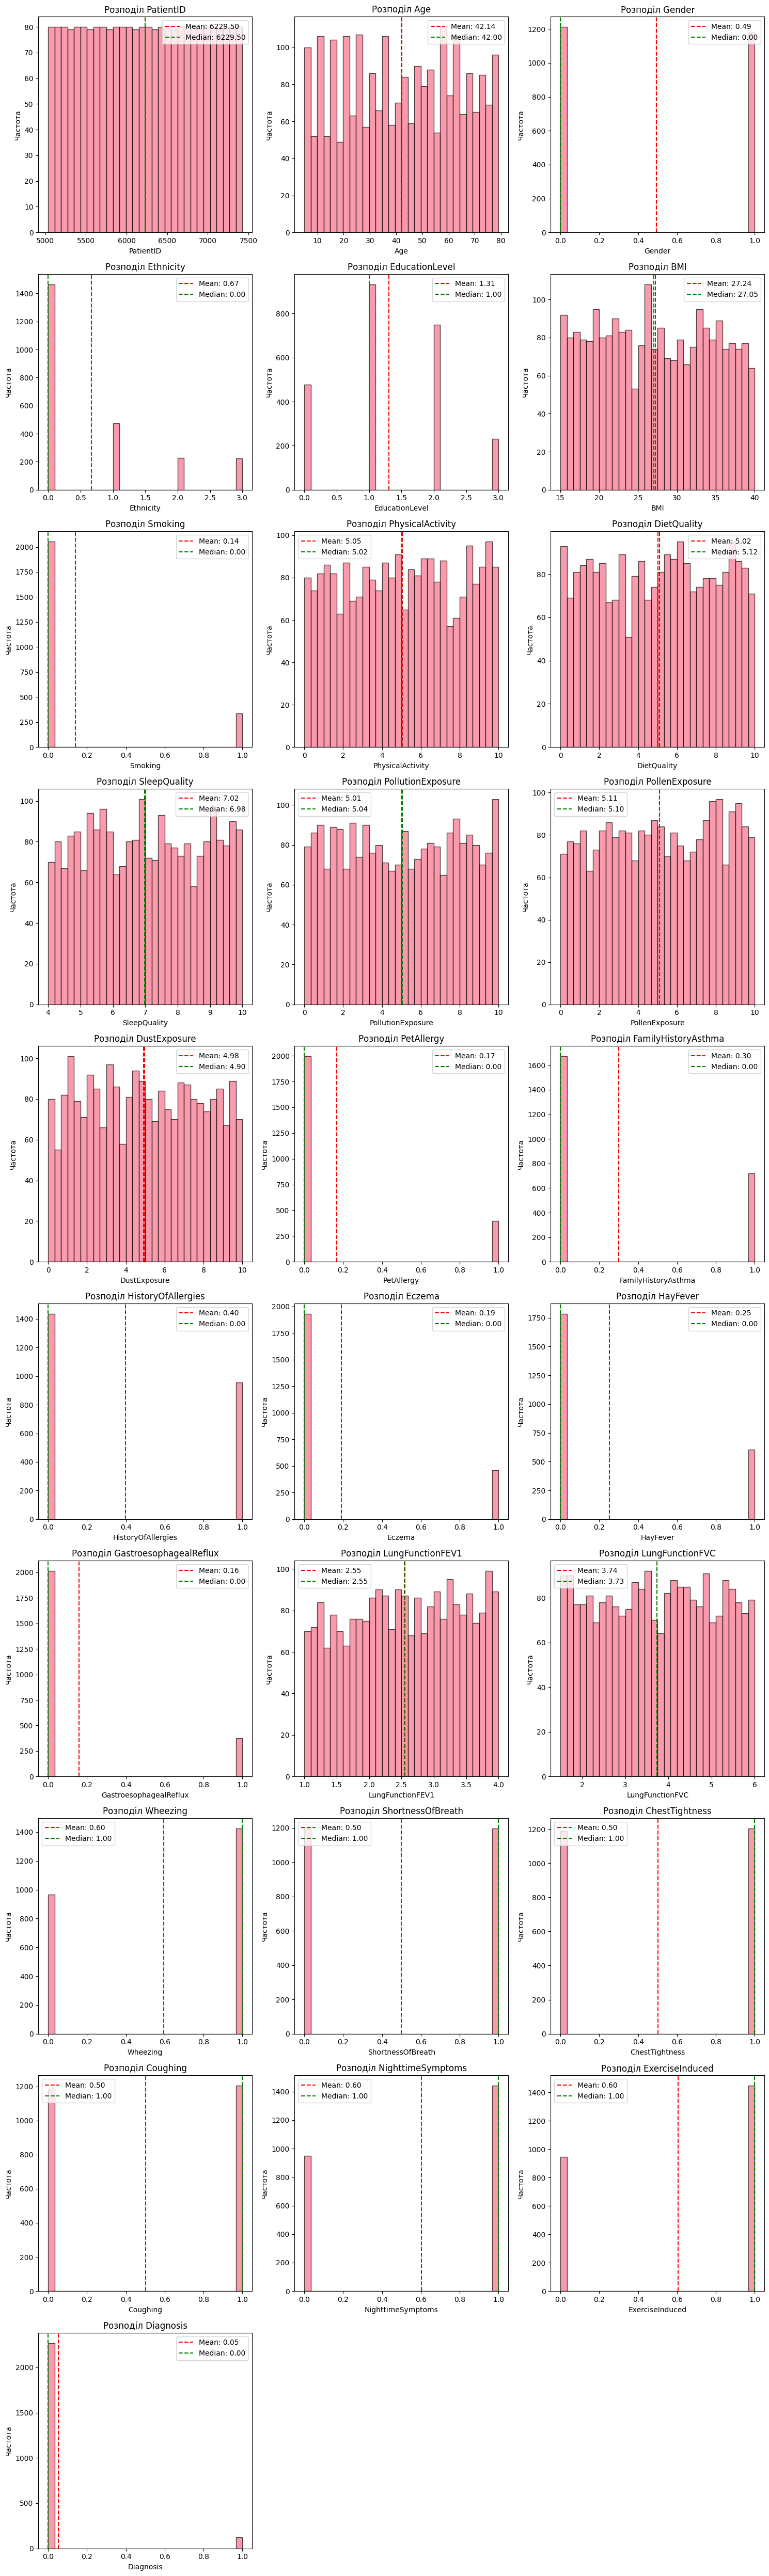

In [71]:
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()

def analyze_numerical_distributions(df, columns):
    n_cols = 3
    n_rows = (len(columns) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, column in enumerate(columns):
        row = i // n_cols
        col = i % n_cols
        
        axes[row, col].hist(df[column].dropna(), bins=30, alpha=0.7, edgecolor='black')
        axes[row, col].set_title(f'Розподіл {column}')
        axes[row, col].set_xlabel(column)
        axes[row, col].set_ylabel('Частота')
        
        mean_val = df[column].mean()
        median_val = df[column].median()
        axes[row, col].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
        axes[row, col].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
        axes[row, col].legend()
    
    for i in range(len(columns), n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        fig.delaxes(axes[row, col])
    
    plt.tight_layout()
    plt.show()
if numerical_columns:
    print("\nАналіз розподілів числових змінних:")
    analyze_numerical_distributions(df, numerical_columns)


In [72]:
def detect_outliers(df):
    
    numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
    outlier_summary = []
    
    for column in numerical_columns:
        data = df[column].dropna()
        
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        iqr_outliers = data[(data < lower_bound) | (data > upper_bound)]
        
        z_scores = np.abs(stats.zscore(data))
        z_outliers = data[z_scores > 3]
        
        outlier_summary.append({
            'Column': column,
            'Total_Values': len(data),
            'IQR_Outliers': len(iqr_outliers),
            'IQR_Percent': (len(iqr_outliers) / len(data)) * 100,
            'Z_Score_Outliers': len(z_outliers),
            'Z_Score_Percent': (len(z_outliers) / len(data)) * 100,
            'Min_Value': data.min(),
            'Max_Value': data.max(),
            'Mean': data.mean(),
            'Std': data.std()
        })
    
    outlier_df = pd.DataFrame(outlier_summary)
    
    
    print("\n" + "="*80)
    print("Аналіз аномалій:")
    print("="*80)
    
    sorted_columns = outlier_df.sort_values('IQR_Percent', ascending=False)
    
    for _, row in sorted_columns.iterrows():
        column = row['Column']
        iqr_percent = row['IQR_Percent']
        z_percent = row['Z_Score_Percent']
        
        print(f"\nКОЛОНКА: {column}")
        print(f"   Загальна кількість значень: {int(row['Total_Values'])}")
        print(f"   Діапазон значень: {row['Min_Value']:.2f} - {row['Max_Value']:.2f}")
        print(f"   Середнє значення: {row['Mean']:.2f} (стандартне відхилення: {row['Std']:.2f})")
        
        if iqr_percent > 15:
            status = "Високий рівень аномалій"
            recommendation = "Обов'язково потрібне очищення даних"
        elif iqr_percent > 5:
            status = "Нормальний рівень аномалій"
            recommendation = "Рекомендується детальна перевірка та можливе очищення"
        elif iqr_percent > 1:
            status = "Низький рівень аномалій"
            recommendation = "Аномалії в допустимих межах, очищення опціональне"
        else:
            status = "Мінімальна кількість аномалій"
            recommendation = "Дані в задовільному стані"
        
        print(f"   Статус: {status}")
        print(f"   IQR метод: {int(row['IQR_Outliers'])} аномалій ({iqr_percent:.1f}%)")
        print(f"   Z-score метод: {int(row['Z_Score_Outliers'])} аномалій ({z_percent:.1f}%)")
        print(f"   Рекомендація: {recommendation}")
    
    total_columns = len(outlier_df)
    critical_columns = len(outlier_df[outlier_df['IQR_Percent'] > 15])
    moderate_columns = len(outlier_df[(outlier_df['IQR_Percent'] > 5) & (outlier_df['IQR_Percent'] <= 15)])
    clean_columns = len(outlier_df[outlier_df['IQR_Percent'] <= 1])
    
    print(f"\n" + "="*80)
    print("ЗАГАЛЬНА СТАТИСТИКА АНАЛІЗУ:")
    print("="*80)
    print(f"Всього числових колонок: {total_columns}")
    print(f"Колонки з критичним рівнем аномалій (>15%): {critical_columns}")
    print(f"Колонки з помірним рівнем аномалій (5-15%): {moderate_columns}")
    print(f"Відносно чисті колонки (≤1%): {clean_columns}")
    
    if critical_columns > 0:
        print(f"\n{critical_columns} колонки бажано пофіксити.")
    elif moderate_columns > 0:
        print(f"\nРекомендується додаткова перевірка {moderate_columns} колонок з помірним рівнем аномалій.")
    else:
        print(f"\nЯкість даних задовільна, критичних проблем не виявлено.")
    
    return outlier_df

outlier_analysis = detect_outliers(df)


Аналіз аномалій:

КОЛОНКА: Eczema
   Загальна кількість значень: 2392
   Діапазон значень: 0.00 - 1.00
   Середнє значення: 0.19 (стандартне відхилення: 0.39)
   Статус: Високий рівень аномалій
   IQR метод: 459 аномалій (19.2%)
   Z-score метод: 0 аномалій (0.0%)
   Рекомендація: Обов'язково потрібне очищення даних

КОЛОНКА: PetAllergy
   Загальна кількість значень: 2392
   Діапазон значень: 0.00 - 1.00
   Середнє значення: 0.17 (стандартне відхилення: 0.37)
   Статус: Високий рівень аномалій
   IQR метод: 397 аномалій (16.6%)
   Z-score метод: 0 аномалій (0.0%)
   Рекомендація: Обов'язково потрібне очищення даних

КОЛОНКА: GastroesophagealReflux
   Загальна кількість значень: 2392
   Діапазон значень: 0.00 - 1.00
   Середнє значення: 0.16 (стандартне відхилення: 0.36)
   Статус: Високий рівень аномалій
   IQR метод: 378 аномалій (15.8%)
   Z-score метод: 0 аномалій (0.0%)
   Рекомендація: Обов'язково потрібне очищення даних

КОЛОНКА: Smoking
   Загальна кількість значень: 2392
   Ді

In [95]:
def generate_data_quality_report(df):
    print("\n=== ЗВІТ ПРО ЯКІСТЬ ДАНИХ ===")
    
    print("\n1. ЗАГАЛЬНА ІНФОРМАЦІЯ")
    print("-" * 50)
    print(f"Розмір датасету: {df.shape[0]:,} записів × {df.shape[1]} колонок")
    print(f"Розмір в пам'яті: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    text_cols = df.select_dtypes(include=['object']).columns.tolist()
    bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
    
    print(f"Числових колонок: {len(numeric_cols)}")
    print(f"Текстових колонок: {len(text_cols)}")
    print(f"Булевих колонок: {len(bool_cols)}")
    
    print("\n2. ПРОПУЩЕНІ ЗНАЧЕННЯ")
    print("-" * 50)
    
    missing_summary = []
    for col in df.columns:
        missing_count = df[col].isnull().sum()
        missing_percent = (missing_count / len(df)) * 100
        if missing_count > 0:
            missing_summary.append((col, missing_count, missing_percent))
    
    if missing_summary:
        missing_summary.sort(key=lambda x: x[1], reverse=True)
        print(f"Колонок з пропусками: {len(missing_summary)} з {len(df.columns)}")
        print("\nНайгірші колонки:")
        for col, count, percent in missing_summary[:5]:
            print(f"  {col}: {count:,} ({percent:.1f}%)")
    else:
        print("Пропущених значень не знайдено")
    
    print("\n3. ДУБЛІКАТИ")
    print("-" * 50)
    
    full_duplicates = df.duplicated().sum()
    print(f"Повністю ідентичних записів: {full_duplicates:,}")
    
    print("\nДублікати по колонках:")
    for col in df.columns:
        total_values = len(df[col].dropna())
        unique_values = df[col].nunique()
        
        if total_values > 0:
            duplicate_count = total_values - unique_values
            if duplicate_count > 0:
                duplicate_percent = (duplicate_count / total_values) * 100
                avg_duplicates_per_value = duplicate_count / unique_values if unique_values > 0 else 0
                print(f"  {col}: {unique_values:,} унікальних, {duplicate_count:,} дублікатів ({duplicate_percent:.1f}%)")
                if avg_duplicates_per_value > 1:
                    print(f"    → В середньому {avg_duplicates_per_value:.1f} дублікатів на унікальне значення")
    
    print("\n4. УНІКАЛЬНІСТЬ ДАНИХ")
    print("-" * 50)
    
    binary_cols = []
    low_cardinality = []
    high_cardinality = []
    perfect_unique = []
    constant_cols = []
    
    for col in df.columns:
        unique_count = df[col].nunique()
        total_count = len(df[col].dropna())
        
        if unique_count == 1:
            constant_cols.append(col)
        elif unique_count == 2 and col not in bool_cols:
            unique_values = df[col].dropna().unique()
            if set(map(str, unique_values)) == {'0', '1'} or set(map(str, unique_values)) == {0, 1}:
                binary_cols.append(col)
            else:
                low_cardinality.append((col, unique_count, list(unique_values)))
        elif unique_count <= 5 and col not in bool_cols and col not in binary_cols:
            low_cardinality.append((col, unique_count, list(df[col].dropna().unique())[:5]))
        elif unique_count == total_count and total_count > 1:
            perfect_unique.append(col)
        elif unique_count / total_count > 0.95 and unique_count > 100:
            high_cardinality.append((col, unique_count, total_count))
    
    if constant_cols:
        print(f"Константні колонки (1 значення): {len(constant_cols)}")
        for col in constant_cols:
            print(f"  - {col}: '{df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'NaN'}'")
    
    if binary_cols:
        print(f"\nБінарні колонки (0/1): {len(binary_cols)}")
        for col in binary_cols[:5]:
            values = df[col].value_counts()
            print(f"  - {col}: {values.to_dict()}")
    
    if low_cardinality:
        print(f"\nМало унікальних значень (2-5): {len(low_cardinality)}")
        for col, count, values in low_cardinality[:5]:
            print(f"  - {col} ({count} значень): {values}")
    
    if perfect_unique:
        print(f"\nКолонки-ідентифікатори (100% унікальність): {len(perfect_unique)}")
        for col in perfect_unique[:3]:
            print(f"  - {col}")
    
    if high_cardinality:
        print(f"\nВисока кардинальність (>95% унікальних): {len(high_cardinality)}")
        for col, unique_count, total_count in high_cardinality[:3]:
            print(f"  - {col}: {unique_count:,} з {total_count:,} ({unique_count/total_count*100:.1f}%)")
    
    print("\n5. ЧИСЛОВІ ДАНІ")
    print("-" * 50)
    
    outlier_analysis = []
    
    if numeric_cols:
        for col in numeric_cols:
            data = df[col].dropna()
            if len(data) > 0:
                Q1 = data.quantile(0.25)
                Q3 = data.quantile(0.75)
                IQR = Q3 - Q1
                
                if IQR > 0:
                    outliers = data[(data < Q1 - 1.5 * IQR) | (data > Q3 + 1.5 * IQR)]
                    outlier_percent = (len(outliers) / len(data)) * 100
                    outlier_analysis.append((col, len(outliers), outlier_percent))
                
                print(f"\n{col}:")
                print(f"  Діапазон: {data.min():.2f} - {data.max():.2f}")
                print(f"  Середнє: {data.mean():.2f}, Медіана: {data.median():.2f}")                
                if data.min() == data.max():
                    print(f" Константне значення: {data.min()}")
    
    print("\n6. РЕКОМЕНДАЦІЇ")
    print("-" * 50)
    
    recommendations = []
    
    if missing_summary:
        high_missing = [col for col, count, percent in missing_summary if percent > 50]
        medium_missing = [col for col, count, percent in missing_summary if 10 < percent <= 50]
        
        if high_missing:
            recommendations.append(f"Розглянути видалення {len(high_missing)} колонок з >50% пропусків")
        if medium_missing:
            recommendations.append(f"Заповнити пропуски в {len(medium_missing)} колонках (10-50% пропусків)")
    
    if full_duplicates > 0:
        recommendations.append(f"Видалити {full_duplicates:,} повністю дублікованих записів")
    
    if constant_cols:
        recommendations.append(f"Видалити {len(constant_cols)} константних колонок (не несуть інформації)")
    
    high_outlier_cols = [col for col, count, percent in outlier_analysis if percent > 15]
    if high_outlier_cols:
        recommendations.append(f"Перевірити аномалії в {len(high_outlier_cols)} колонках (>15% викидів)")
    
    if len(perfect_unique) > 3:
        recommendations.append(f"Перевірити необхідність {len(perfect_unique)} колонок-ідентифікаторів")
    
    if not recommendations:
        recommendations.append("Дані в хорошому стані, серйозних проблем не виявлено")
    
    for i, rec in enumerate(recommendations, 1):
        print(f"{i}. {rec}")
    
    total_issues = len([x for x in [missing_summary, constant_cols, high_outlier_cols] if x])
    quality_score = "ПОТРЕБУЄ ОЧИЩЕННЯ" if total_issues > 2 or full_duplicates > len(df) * 0.05 else "Якісь нормальна"
    
    print(f"\n{'='*50}")
    print(f"ЗАГАЛЬНА ОЦІНКА: {quality_score}")
    
generate_data_quality_report(df)


=== ЗВІТ ПРО ЯКІСТЬ ДАНИХ ===

1. ЗАГАЛЬНА ІНФОРМАЦІЯ
--------------------------------------------------
Розмір датасету: 2,392 записів × 32 колонок
Розмір в пам'яті: 0.6 MB
Числових колонок: 14
Текстових колонок: 2
Булевих колонок: 15

2. ПРОПУЩЕНІ ЗНАЧЕННЯ
--------------------------------------------------
Пропущених значень не знайдено

3. ДУБЛІКАТИ
--------------------------------------------------
Повністю ідентичних записів: 0

Дублікати по колонках:
  age: 75 унікальних, 2,317 дублікатів (96.9%)
    → В середньому 30.9 дублікатів на унікальне значення
  gender: 2 унікальних, 2,390 дублікатів (99.9%)
    → В середньому 1195.0 дублікатів на унікальне значення
  ethnicity: 4 унікальних, 2,388 дублікатів (99.8%)
    → В середньому 597.0 дублікатів на унікальне значення
  educationlevel: 4 унікальних, 2,388 дублікатів (99.8%)
    → В середньому 597.0 дублікатів на унікальне значення
  smoking: 2 унікальних, 2,390 дублікатів (99.9%)
    → В середньому 1195.0 дублікатів на унікальне з

In [76]:
task_text = """
## Завдання 4
Створіть реляційну базу даних на основі набору даних з Kaggle. На початковому етапі допускається створення однієї таблиці, яка міститиме всі поля з CSV-файлу.

До кожного запису обов’язково додайте поле timestamp — дату та час, згенеровані випадковим чином у межах 2025 року (з січня по грудень). Це поле буде використовуватись у лабораторній роботі 5 для аналізу змін у часі.
"""
display(Markdown(task_text))


## Завдання 4
Створіть реляційну базу даних на основі набору даних з Kaggle. На початковому етапі допускається створення однієї таблиці, яка міститиме всі поля з CSV-файлу.

До кожного запису обов’язково додайте поле timestamp — дату та час, згенеровані випадковим чином у межах 2025 року (з січня по грудень). Це поле буде використовуватись у лабораторній роботі 5 для аналізу змін у часі.


In [86]:
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
from datetime import datetime, timedelta
import random
import os

DATABASE_CONFIG = {
    'host': 'localhost',
    'database': 'breathwell_clinic',
    'user': 'postgres',
    'password': '0702',
    'port': '5432'
}

def generate_random_timestamp():
    start_date = datetime(2025, 1, 1)
    end_date = datetime(2025, 12, 31)
    time_between = end_date - start_date
    days_between = time_between.days
    random_number_of_days = random.randrange(days_between)
    random_hour = random.randint(0, 23)
    random_minute = random.randint(0, 59)
    random_second = random.randint(0, 59)
    
    return start_date + timedelta(
        days=random_number_of_days,
        hours=random_hour,
        minutes=random_minute,
        seconds=random_second
    )

def clean_and_prepare_data(csv_file_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_file_path)
    
    df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')
    df.columns = df.columns.str.replace('(', '').str.replace(')', '').str.replace('/', '_')
    
    df['timestamp'] = [generate_random_timestamp() for _ in range(len(df))]
    
    for col in df.columns:
        if col == 'timestamp':
            continue
            
        unique_values = df[col].dropna().unique()
        
        if set(map(str, unique_values)).issubset({'0', '1', 'True', 'False', 'YES', 'NO', 'Yes', 'No'}):
            df[col] = df[col].map({
                '1': True, '0': False, 1: True, 0: False,
                'True': True, 'False': False,
                'YES': True, 'NO': False,
                'Yes': True, 'No': False
            })
            df[col] = df[col].fillna(False)
            
        elif df[col].dtype in ['int64', 'float64']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].fillna(df[col].median())
            
        else:
            df[col] = df[col].astype(str)
            df[col] = df[col].replace('nan', 'Unknown')
            df[col] = df[col].fillna('Unknown')
    
    return df

def import_to_database(df: pd.DataFrame, table_name: str = 'asthma_patients_data'):
    connection_string = (
        f"postgresql://{DATABASE_CONFIG['user']}:{DATABASE_CONFIG['password']}"
        f"@{DATABASE_CONFIG['host']}:{DATABASE_CONFIG['port']}"
        f"/{DATABASE_CONFIG['database']}"
    )
    
    try:
        engine = create_engine(connection_string)
        df.to_sql(table_name, engine, if_exists='replace', index=False, method='multi', chunksize=500)
        return True
    except:
        return False

def main():
    csv_file = "asthma_disease_data.csv"
    
    if not os.path.exists(csv_file):
        print("Файл не знайдено")
        return
    
    try:
        df = clean_and_prepare_data(csv_file)
        success = import_to_database(df, 'asthma_patients_data')
        
        if success:
            print(f"На привелике диво дані імпортувались і сервіс постгрес якимось чином запустився 🙀: {df.shape[0]} рядків, {df.shape[1]} колонок")
        else:
            print("Мій імпорт впав -_-")
            
    except:
        print("Критична помилка")

if __name__ == "__main__":
    main()

На привелике диво дані імпортувались і сервіс постгрес якимось чином запустився 🙀: 2392 рядків, 30 колонок


In [94]:
task_text = """
## Завдання 5
Оберіть один із популярних інструментів для візуалізації даних (BI Tools), підключіть його до створеної БД, проведіть візуалізацію даних та надайте короткий висновок щодо отриманих графіків.

"""
display(Markdown(task_text))


## Завдання 5
Оберіть один із популярних інструментів для візуалізації даних (BI Tools), підключіть його до створеної БД, проведіть візуалізацію даних та надайте короткий висновок щодо отриманих графіків.



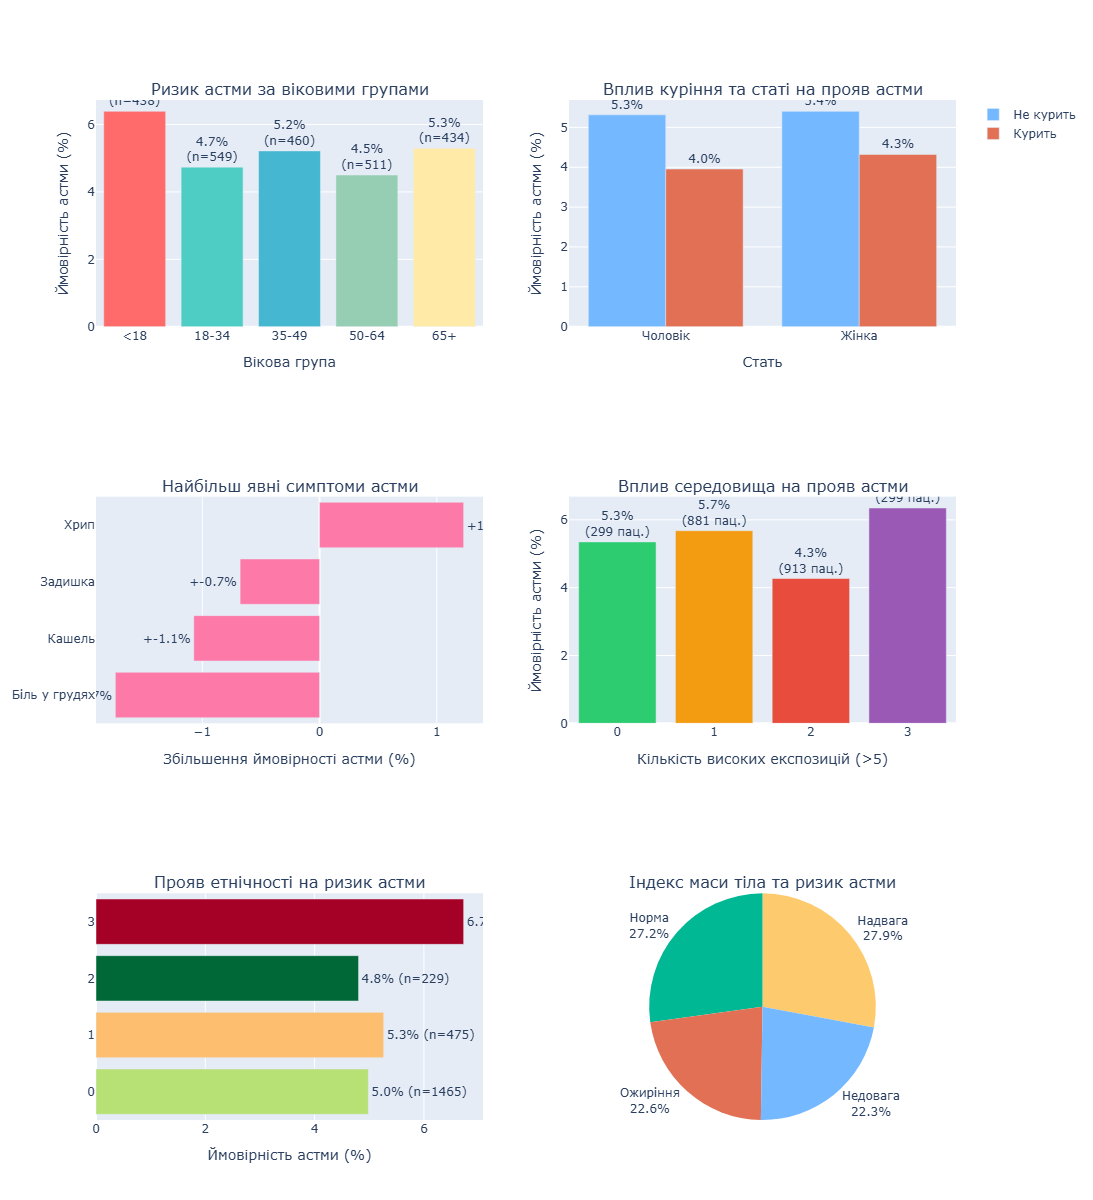

In [93]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.subplots as sp
from plotly.subplots import make_subplots
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

DATABASE_CONFIG = {
    'host': 'localhost',
    'database': 'breathwell_clinic',
    'user': 'postgres',
    'password': '0702',
    'port': '5432'
}

def load_data_from_db():
    connection_string = (
        f"postgresql://{DATABASE_CONFIG['user']}:{DATABASE_CONFIG['password']}"
        f"@{DATABASE_CONFIG['host']}:{DATABASE_CONFIG['port']}"
        f"/{DATABASE_CONFIG['database']}"
    )
    
    engine = create_engine(connection_string)
    df = pd.read_sql("SELECT * FROM asthma_patients_data", engine)
    return df

df = load_data_from_db()

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[
        'Ризик астми за віковими групами',
        'Вплив куріння та статі на прояв астми',
        'Найбільш явні симптоми астми',
        'Вплив середовища на прояв астми',
        'Прояв етнічності на ризик астми',
        'Індекс маси тіла та ризик астми'
    ],
    specs=[[{"type": "bar"}, {"type": "bar"}],
           [{"type": "bar"}, {"type": "scatter"}],
           [{"type": "bar"}, {"type": "pie"}]]
)

if 'age' in df.columns:
    age_groups = pd.cut(df['age'], bins=[0, 18, 35, 50, 65, 100], 
                       labels=['<18', '18-34', '35-49', '50-64', '65+'])
    age_asthma = df.groupby(age_groups)['diagnosis'].agg(['mean', 'count']).reset_index()
    
    fig.add_trace(
        go.Bar(
            x=age_asthma['age'].astype(str),
            y=age_asthma['mean'] * 100,
            marker_color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'],
            text=[f'{rate:.1f}%<br>(n={count})' for rate, count in zip(age_asthma['mean']*100, age_asthma['count'])],
            textposition='outside',
            showlegend=False
        ),
        row=1, col=1
    )

if 'gender' in df.columns and 'smoking' in df.columns:
    df['gender_display'] = df['gender'].map({True: 'Жінка', False: 'Чоловік', 1: 'Жінка', 0: 'Чоловік'}).fillna(df['gender'].astype(str))
    
    gender_smoke_data = []
    for gender in df['gender_display'].unique():
        for smoking in [False, True]:
            subset = df[(df['gender_display'] == gender) & (df['smoking'] == smoking)]
            if len(subset) > 0:
                asthma_rate = subset['diagnosis'].mean() * 100
                gender_smoke_data.append({
                    'Gender': gender,
                    'Smoking': 'Курить' if smoking else 'Не курить',
                    'AsthmaRate': asthma_rate,
                    'Count': len(subset)
                })
    
    smoke_df = pd.DataFrame(gender_smoke_data)
    if not smoke_df.empty:
        non_smokers = smoke_df[smoke_df['Smoking'] == 'Не курить']
        smokers = smoke_df[smoke_df['Smoking'] == 'Курить']
        
        fig.add_trace(
            go.Bar(
                x=non_smokers['Gender'],
                y=non_smokers['AsthmaRate'],
                name='Не курить',
                marker_color='#74B9FF',
                text=[f'{rate:.1f}%' for rate in non_smokers['AsthmaRate']],
                textposition='outside'
            ),
            row=1, col=2
        )
        
        fig.add_trace(
            go.Bar(
                x=smokers['Gender'],
                y=smokers['AsthmaRate'],
                name='Курить',
                marker_color='#E17055',
                text=[f'{rate:.1f}%' for rate in smokers['AsthmaRate']],
                textposition='outside'
            ),
            row=1, col=2
        )

symptoms = ['wheezing', 'shortnessofbreath', 'coughing', 'chesttightness']
available_symptoms = [s for s in symptoms if s in df.columns]

if available_symptoms:
    symptom_data = []
    for symptom in available_symptoms:
        with_symptom = df[df[symptom] == True]['diagnosis'].mean() * 100
        without_symptom = df[df[symptom] == False]['diagnosis'].mean() * 100
        symptom_data.append({
            'Symptom': symptom.replace('shortnessofbreath', 'Задишка').replace('chesttightness', 'Біль у грудях').replace('wheezing', 'Хрип').replace('coughing', 'Кашель'),
            'Difference': with_symptom - without_symptom
        })
    
    symptom_df = pd.DataFrame(symptom_data).sort_values('Difference', ascending=True)
    
    fig.add_trace(
        go.Bar(
            y=symptom_df['Symptom'],
            x=symptom_df['Difference'],
            orientation='h',
            marker_color='#FD79A8',
            text=[f'+{diff:.1f}%' for diff in symptom_df['Difference']],
            textposition='outside',
            showlegend=False
        ),
        row=2, col=1
    )

env_factors = ['dustexposure', 'pollutionexposure', 'pollenexposure']
available_env = [f for f in env_factors if f in df.columns]

if available_env:
    exposure_levels = []
    for i, row in df.iterrows():
        high_exposures = sum([1 for factor in available_env if row[factor] > 5])
        exposure_levels.append(high_exposures)
    
    df['ExposureLevel'] = exposure_levels
    env_stats = df.groupby('ExposureLevel').agg({
        'diagnosis': ['mean', 'count']
    }).round(4)
    env_stats.columns = ['asthma_rate', 'patient_count']
    env_stats = env_stats.reset_index()
    
    if len(env_stats) > 1:
        colors = ['#2ECC71', '#F39C12', '#E74C3C', '#9B59B6']
        bar_colors = [colors[min(i, len(colors)-1)] for i in env_stats['ExposureLevel']]
        
        fig.add_trace(
            go.Bar(
                x=env_stats['ExposureLevel'],
                y=env_stats['asthma_rate'] * 100,
                marker_color=bar_colors,
                text=[f'{rate*100:.1f}%<br>({count} пац.)' for rate, count in zip(env_stats['asthma_rate'], env_stats['patient_count'])],
                textposition='outside',
                showlegend=False
            ),
            row=2, col=2
        )

if 'ethnicity' in df.columns:
    ethnicity_stats = df.groupby('ethnicity')['diagnosis'].agg(['mean', 'count']).reset_index()
    ethnicity_stats = ethnicity_stats[ethnicity_stats['count'] >= 10]
    ethnicity_stats = ethnicity_stats.sort_values('mean', ascending=True)
    
    fig.add_trace(
        go.Bar(
            y=ethnicity_stats['ethnicity'],
            x=ethnicity_stats['mean'] * 100,
            orientation='h',
            marker_color=np.linspace(0.3, 0.9, len(ethnicity_stats)),
            marker_colorscale='RdYlGn_r',
            text=[f'{rate*100:.1f}% (n={count})' for rate, count in zip(ethnicity_stats['mean'], ethnicity_stats['count'])],
            textposition='outside',
            showlegend=False
        ),
        row=3, col=1
    )

if 'bmi' in df.columns:
    bmi_categories = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 50], 
                           labels=['Недовага', 'Норма', 'Надвага', 'Ожиріння'])
    bmi_asthma = df.groupby(bmi_categories)['diagnosis'].agg(['mean', 'count']).reset_index()
    bmi_asthma = bmi_asthma.dropna()
    
    fig.add_trace(
        go.Pie(
            labels=bmi_asthma['bmi'],
            values=bmi_asthma['mean'],
            marker_colors=['#74B9FF', '#00B894', '#FDCB6E', '#E17055'],
            textinfo='label+percent',
            textposition='outside',
            showlegend=False
        ),
        row=3, col=2
    )

fig.update_layout(
    height=1200,
    showlegend=True
)

fig.update_xaxes(title_text="Вікова група", row=1, col=1)
fig.update_yaxes(title_text="Ймовірність астми (%)", row=1, col=1)

fig.update_xaxes(title_text="Стать", row=1, col=2)
fig.update_yaxes(title_text="Ймовірність астми (%)", row=1, col=2)

fig.update_xaxes(title_text="Збільшення ймовірності астми (%)", row=2, col=1)

fig.update_xaxes(title_text="Кількість високих експозицій (>5)", row=2, col=2)
fig.update_yaxes(title_text="Ймовірність астми (%)", row=2, col=2)

fig.update_xaxes(title_text="Ймовірність астми (%)", row=3, col=1)

fig.show()

In [99]:
task_text = """
## Висновок
Як показують графіки дослідження прояву астми за певними критеріями, можна замітити що здебільшого астму мають люди вікової категорі 18 і нижче.
На незрозуміле диво люди які курять мають менший шанс отримати астму ніж ті що курять.. (проте слід розуміти що графік візуалізує лише 2 критерї з 26)
Найменший ризик хворіння астмою є у людей Азійського походження, а найбільший в "Інших".
А також найбільш явним симптомом астми є - хрип. Загалом за допомогою цих досліджень я дізнався багато потрібних речей для виконання моїх бізнес-цілей.
"""
display(Markdown(task_text))


## Висновок
Як показують графіки дослідження прояву астми за певними критеріями, можна замітити що здебільшого астму мають люди вікової категорі 18 і нижче.
На незрозуміле диво люди які курять мають менший шанс отримати астму ніж ті що курять.. (проте слід розуміти що графік візуалізує лише 2 критерї з 26)
Найменший ризик хворіння астмою є у людей Азійського походження, а найбільший в "Інших".
А також найбільш явним симптомом астми є - хрип. Загалом за допомогою цих досліджень я дізнався багато потрібних речей для виконання моїх бізнес-цілей.
